# Exercise 8.4 — Period-Doubling Bifurcation in a Discrete-Time System

## Problem

Consider the discrete-time dynamical system:

$$x_t = (1-a)x_{t-1} + ax_{t-1}^3 \qquad (8.41)$$

The point $x^* = 0$ is an equilibrium. Find the value of $a$ at which $x^* = 0$ undergoes its first period-doubling bifurcation.

## Derivation

### Step 1 — Confirm the equilibrium

Define the map $f(x) = (1-a)x + ax^3$. Substituting $x^* = 0$:

$$f(0) = (1-a)(0) + a(0)^3 = 0 \checkmark$$

### Step 2 — Stability of $x^* = 0$

For a discrete map, the stability of a fixed point is determined by the magnitude of the derivative of $f$ at that point. Compute:

$$f'(x) = (1-a) + 3ax^2$$

At $x^* = 0$:

$$f'(0) = 1 - a$$

The fixed point is stable when $|f'(0)| < 1$, i.e., $|1-a| < 1$, which gives $0 < a < 2$.

### Step 3 — Period-Doubling Bifurcation Condition

A period-doubling bifurcation occurs at a fixed point when the multiplier (derivative of the map) passes through $-1$:

$$f'(0) = -1$$

$$1 - a = -1$$

$$\boxed{a = 2}$$

### Step 4 — Verify a Period-2 Cycle Emerges for $a > 2$

Since $f$ is an odd function ($f(-x) = -f(x)$), any period-2 orbit must satisfy $x_2 = -x_1$, meaning we need $f(x_1) = -x_1$:

$$(1-a)x_1 + ax_1^3 = -x_1$$

$$ax_1^3 + (2-a)x_1 = 0 \implies x_1\left[ax_1^2 + (2-a)\right] = 0$$

The non-trivial ($x_1 \neq 0$) solution:

$$x_1^2 = \frac{a-2}{a}$$

This has real solutions only when $a > 2$, confirming that the period-2 cycle **bifurcates from $x^* = 0$ at $a = 2$**.

| Regime | Behavior of $x^* = 0$ |
|:------:|:---------------------:|
| $0 < a < 2$ | Stable fixed point |
| $a = 2$ | Period-doubling bifurcation |
| $a > 2$ | Unstable fixed point; stable period-2 orbit at $x_1 = \pm\sqrt{(a-2)/a}$ |

In [1]:
import numpy as np
import matplotlib.pyplot as plt

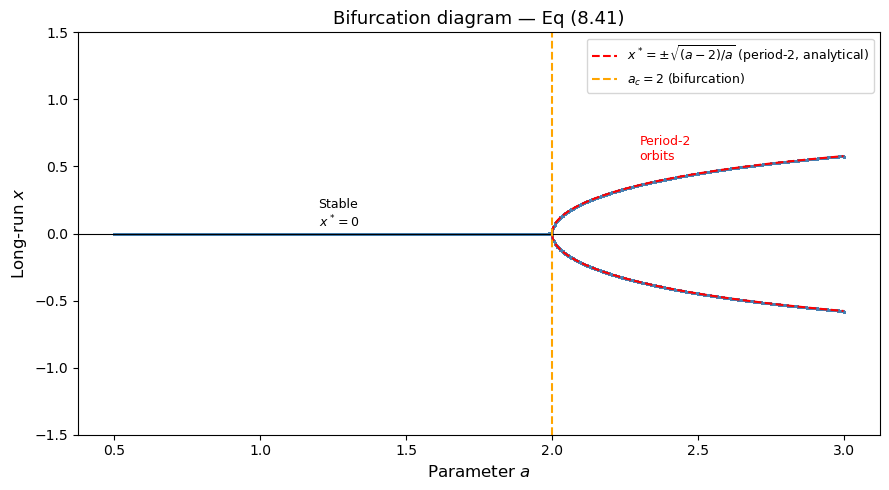

In [2]:
# --- Bifurcation diagram: iterate the map and plot long-run behavior vs a ---

def f_map(x, a):
    return (1 - a) * x + a * x**3

a_vals = np.linspace(0.5, 3.0, 1000)
n_transient = 500
n_plot = 150

bif_a = []
bif_x = []

for a in a_vals:
    x = 0.1  # small nonzero initial condition to avoid the trivial orbit
    for _ in range(n_transient):
        x = f_map(x, a)
    for _ in range(n_plot):
        x = f_map(x, a)
        bif_a.append(a)
        bif_x.append(x)

# Analytical period-2 branches
a_p2 = np.linspace(2.0, 3.0, 300)
x_p2_pos = np.sqrt((a_p2 - 2) / a_p2)
x_p2_neg = -x_p2_pos

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(bif_a, bif_x, s=0.4, color='steelblue', alpha=0.5)
ax.plot(a_p2, x_p2_pos, 'r--', lw=1.5, label='$x^* = \\pm\\sqrt{(a-2)/a}$ (period-2, analytical)')
ax.plot(a_p2, x_p2_neg, 'r--', lw=1.5)
ax.axhline(0, color='k', lw=0.8)
ax.axvline(2.0, color='orange', lw=1.5, ls='--', label='$a_c = 2$ (bifurcation)')
ax.set_xlabel('Parameter $a$', fontsize=12)
ax.set_ylabel('Long-run $x$', fontsize=12)
ax.set_title('Bifurcation diagram — Eq (8.41)', fontsize=13)
ax.legend(fontsize=9)
ax.set_ylim(-1.5, 1.5)
ax.annotate('Stable\n$x^*=0$', xy=(1.2, 0.05), fontsize=9)
ax.annotate('Period-2\norbits', xy=(2.3, 0.55), fontsize=9, color='red')
plt.tight_layout()
plt.show()

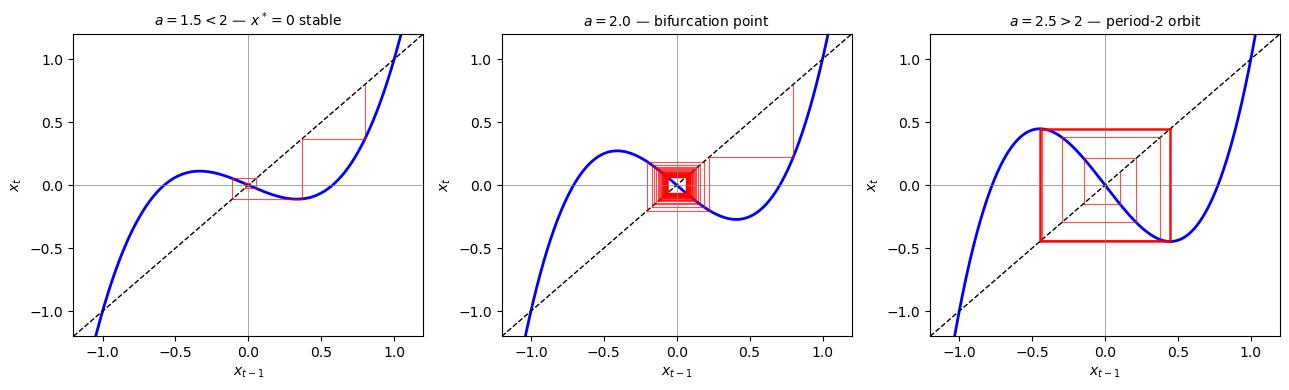

In [3]:
# --- Cobweb diagrams: before, at, and after the bifurcation ---

def cobweb(ax, a, x0, n_steps, title):
    x_range = np.linspace(-1.2, 1.2, 400)
    y_range = [f_map(x, a) for x in x_range]

    ax.plot(x_range, y_range, 'b', lw=2, label='$f(x)$')
    ax.plot(x_range, x_range, 'k--', lw=1, label='$y=x$')

    x = x0
    for _ in range(n_steps):
        x_new = f_map(x, a)
        ax.plot([x, x], [x, x_new], 'r', lw=0.8, alpha=0.7)
        ax.plot([x, x_new], [x_new, x_new], 'r', lw=0.8, alpha=0.7)
        x = x_new

    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('$x_{t-1}$')
    ax.set_ylabel('$x_t$')

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
cobweb(axes[0], a=1.5, x0=0.8,  n_steps=40, title='$a = 1.5 < 2$ — $x^*=0$ stable')
cobweb(axes[1], a=2.0, x0=0.8,  n_steps=60, title='$a = 2.0$ — bifurcation point')
cobweb(axes[2], a=2.5, x0=0.1,  n_steps=60, title='$a = 2.5 > 2$ — period-2 orbit')
plt.tight_layout()
plt.show()

## Summary

The equilibrium $x^* = 0$ of the map $f(x) = (1-a)x + ax^3$ undergoes a **period-doubling bifurcation at $a = 2$**.

- The condition $f'(0) = 1 - a = -1$ gives the critical value $a_c = 2$.
- For $0 < a < 2$: $x^* = 0$ is a stable fixed point.
- At $a = 2$: the multiplier hits $-1$ and the fixed point loses stability.
- For $a > 2$: $x^* = 0$ is unstable and a stable period-2 orbit emerges at $x = \pm\sqrt{(a-2)/a}$, which is confirmed analytically and visible in both the bifurcation diagram and cobweb plots.